# Data Augmentation I

**Date**: Thursday Sept 12, 2024

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/practical-epidemics/blob/master/site/source/iddinf/11_data_augmentation_mcmc_1.ipynb)




In [1]:
from warnings import warn

try:
    import google.colab
    !pip install gemlib
except:
    warn("Not running in Colab, make sure `gemlib` is installed locally")
    
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist, squareform
import tensorflow_probability.substrates.jax as tfp

import gemlib
from gemlib.distributions import DiscreteTimeStateTransitionModel

tfd = tfp.distributions

%matplotlib inline

/tmp/ipykernel_487876/942668653.py:7: UserWarning: Not running in Colab, make sure `gemlib` is installed locally
  warn("Not running in Colab, make sure `gemlib` is installed locally")


## LEARNING OUTCOMES

* Understand what censored event data is, and why it presents a challenge for parameter inference
* Understand how to fit epidemic models to censored event data
* Understand in principle how the move events algorithm works

## Introduction


Generally, outbreak data only captures a partially observed epidemic process. As there are time-dependent quantities in the likelihood we cannot evaluate it with missing event times. One way of tackling censored data is to use a likelihood free method of conducting inference (such as ABC).

Alternatively, we can try to augment the data to estimate the unobserved epidemiological event times. In a Bayesian setting we can simply treat missing event (transition) times as parameters to be estimated.

A fully observed epidemic at a metapopulation level, would mean we know how many units experienced an event at each time point.

At an individual level, the time of each of their epidemic events (transitions between states) would be recorded. This might look something like this:



In [2]:
import numpy as np
import pandas as pd

unit_id = np.arange(0,10)
infection_times = np.random.randint(low=1, high=20, size=10).astype(np.float32)
removal_times = np.random.randint(low=1, high=20, size=10).astype(np.float32)

line_list = pd.DataFrame({'unit_id': unit_id,
                        'SI transition time': infection_times,
                        'IR transition time': removal_times}
                        ).set_index('unit_id')
line_list

,SI transition time,IR transition time
unit_id,,
0,7.0,15.0
1,7.0,15.0
2,14.0,3.0
3,4.0,15.0
4,5.0,7.0
5,13.0,15.0
6,19.0,1.0
7,19.0,17.0
8,15.0,18.0


Whereas data from a partially observed epidemic, with missing infection times for example, would look more like this:


In [3]:
unobserved_infection_times = np.nan

censored_line_list =pd.DataFrame({'unit_id': unit_id,
                        'SI transition time': unobserved_infection_times,
                        'IR transition time': removal_times}
                        ).set_index('unit_id')
censored_line_list

,SI transition time,IR transition time
unit_id,,
0,NaN,15.0
1,NaN,15.0
2,NaN,3.0
3,NaN,15.0
4,NaN,7.0
5,NaN,15.0
6,NaN,1.0
7,NaN,17.0
8,NaN,18.0


This morning, we will think about how we can estimate missing infection times by adding them as parameters to a MCMC algorithm.

## Example model: the spatial individual-level SIR model

We'll take as our example a spatially-explicit population of 50 individuals.  We'll then let the force of infection between individuals depend on distance.

### Defining a spatial population

First, let's simulate the spatial population structure, assuming _complete spatial randomness_, i.e. that individuals are distributed uniformly over a study region.

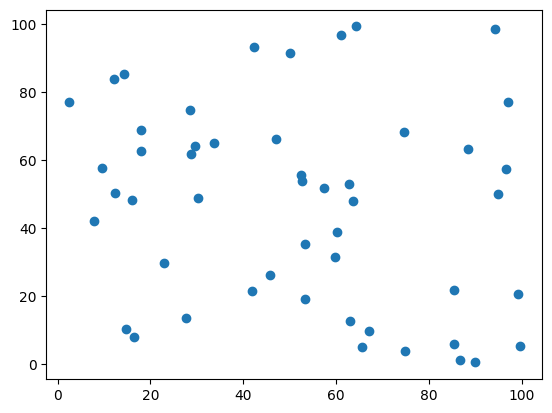

In [4]:
# Defining epidemic model parameters
POPSIZE = 50

coords = jax.random.uniform(
    jax.random.key(0), minval=0.0, maxval=100.0, shape=[POPSIZE, 2]
)
plt.plot(coords[:,0], coords[:,1], "o")

Now we'll compute the pairwise distances between all points, to give a `[POPSIZE,POPSIZE]` distance matrix.

In [5]:
distance_matrix = squareform(pdist(coords))

### A spatial SIR model

For the purposes of exposition, we'll define a spatial SIR model, i.e. one in which the force of infection is determined by the spatial relationship between individuals.  In particular, we'll assume that
$$
\lambda^{SI}_i(t, X) = \beta \sum_{j=1}^{N} \mathbf{1}_{\{x^{I}_{jt} = 1\}}e^{-\phi d_{ij}}
$$
where $d_{ij}$ is the (Euclidean) distance between $i$ and $j$. 

As usual, we define the initial state (with the initial infected individual), SIR incidence matrix, and the SIR model factory function.

In [6]:
def spatial_sir(beta, phi, gamma, initial_state, name):
    
    incidence_matrix = np.array(
        [ #  SI  IR
            [-1,  0],  # S
            [ 1, -1],  # I
            [ 0,  1], # R
        ],
    )

    def si_rate(t, state):
        return beta * jnp.matvec(jnp.exp(-phi * distance_matrix), state[:, 1])
    
    def ir_rate(t, state):
        return gamma
    
    return DiscreteTimeStateTransitionModel(
        transition_rate_fn=[si_rate, ir_rate],
        incidence_matrix=incidence_matrix,
        initial_state=initial_state,
        num_steps=75,
        name=name,
    )

Now we construct the overall Bayesian probabilistic model, encapsulating any covariate data (including, in this case, the initial conditions), and placing priors on the parameters $\beta$, $\phi$, and $\gamma$.

In [7]:
@tfd.JointDistributionCoroutineAutoBatched
def model():
    
    # Constants
    initial_state = np.concatenate(
        [
            [[0, 1, 0]], # Initial infected
            np.repeat([[1, 0, 0]], POPSIZE-1, axis=0) # Everybody else susceptible
        ],
        axis=0,
    )

    # Prior
    beta = yield tfd.Gamma(
      concentration=3.0, rate=2.0, name="beta",
    )

    phi = yield tfd.Gamma(
      concentration=0.1, rate=0.1, name="phi"
    )

    gamma = yield tfd.Gamma(
      concentration=2.0, rate=1.0, name="gamma"
    )

    yield spatial_sir(beta, phi, gamma, initial_state, name="sir")

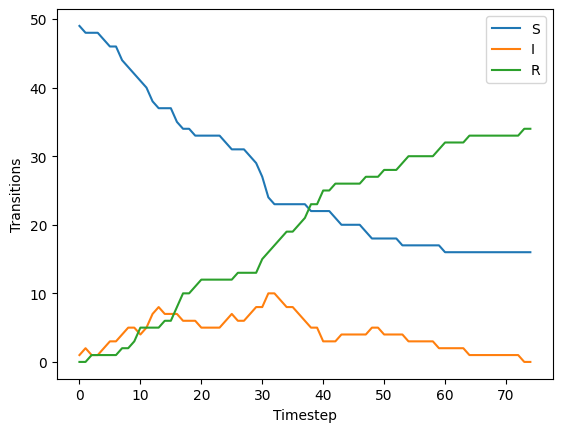

In [8]:
# simulate from the epidemic model to provide initial event times for fitting
dists, sim = model.sample_distributions(beta=0.1, phi=0.1, gamma=0.14, seed=jax.random.key(4))
sim_state = dists.sir.compute_state(sim.sir)

plt.plot(np.sum(sim_state, axis=1), label=["S", "I", "R"])
plt.xlabel("Timestep")
plt.ylabel("Transitions")
plt.legend()

## The Move algorithm

The move algorithm explores the posterior distribution of the censored event times. If we were modelling SARS-CoV-2, a likely set of infection data may be positive test results. We could assume that from the testing dataset we know which individuals were infected. However, the testing data would not provide the time that inidividuals were initially infected. We could therefore provide some initial infection times for each individual who tested positive and use a move algorithm to estimate their SI transition event (infection time).

The move algorithm for a discrete-time SIR model is shown in Algorithm {prf:ref}`alg-move-events`.



```{prf:algorithm} The move events algorithm for an individual-level model
:label: alg-move-events

**Input:** $q(\cdot)$ proposal distribution, $\pi(\cdot)$ a target distribution

**Initialise:** $z^{0}$


1. Choose an event, time *t* and unit *i*, to move:

$$t, i \sim \mbox{Uniform}\{t, i: z_{it}>0\}$$

2. Choose a new time to which to move the event:

 $$t^\prime \sim \mbox{Discrete}(\mathcal{T})$$
 where $\mathcal{T} = \{0\,\dots,T-1\} \cap \{t-\delta_{max},\dots,t+\delta_{max}\} \setminus \{t\}$, i.e. the set of times $t \pm \delta_{max}$ which does _not_ include $t$ or allow us to propose outside the time window represented by the specified model.

3. Update event matrix. Let:

$$z^\star_{it} = z_{it} - 1$$

$$z_{it^\prime + \delta}^\star = z_{it^\prime} + 1$$


4. Compute the acceptance probability

$$\alpha(z, z^\star) = 1 \wedge \frac{\pi(z^\star | \cdot)q(z | z\star)}{\pi(z | \cdot)q(z^\star|z)}$$

As we are using a symmetric proposal for the event moves, the q ratio cancels. i.e. $||z_{it}^\star > 0|| = ||z_{it} > 0||$

```

## Hand-coding the Move algorithm

In this section, we've set an exercise for you to code up Algorithm {prf:ref}`alg-move-events`.  For now, we'll just focus on exploring the posterior distribution over the $S\rightarrow I$ transition for each individual in our population, assuming (unrealistically) that we know the values of the parameters $\beta$, $\phi$, and $\gamma$.  In the next section we'll demonstrate how to it in a Metropolis-within-Gibbs sampler capable of sampling from the entire joint posterior distribution over the parameters and $S\rightarrow I$ together.

For the following exercise, we'll condition the model on "known" values of $\beta$, $\phi$, and $\gamma$, and retrieve the (un-normalized) conditional posterior distribution function for the event times  